# Logistic Regression vs. Gaussian Naive Bayes

## Discriminative vs. Generative Classification

These two classifiers take fundamentally different approaches to the same problem:

| | Logistic Regression | Gaussian Naive Bayes |
|---|---|---|
| **Strategy** | *Discriminative* — directly models P(y \| x) | *Generative* — models P(x \| y) and applies Bayes' theorem |
| **Learns** | A decision boundary between classes | A probability distribution for each class |
| **Assumption** | No strong assumption on feature distributions | Features are independent Gaussians given the class |
| **Training** | Gradient descent on log-loss | Closed-form: compute means & variances per class |

Your job: run both on the same dataset, measure their performance, and figure out where they agree and where they diverge — and *why*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

plt.rc('figure', figsize=(10, 4))
sns.set_style('darkgrid')

## The Dataset: Breast Cancer Wisconsin

569 tumour biopsies, each described by 30 numeric features (mean, standard error, and worst value of 10 cell-nucleus measurements: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).

**Target**: 0 = malignant (212 cases), 1 = benign (357 cases).

One thing to watch: many features are *highly correlated* with each other (radius, perimeter, and area, for example, are nearly redundant). That correlation will matter when we compare the two models.

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='diagnosis')  # 0=malignant, 1=benign

print(f'{len(X)} samples, {X.shape[1]} features')
print(f'Class distribution:\n{y.value_counts().rename({0:"malignant",1:"benign"})}')
X.describe().round(2)

569 samples, 30 features
Class distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


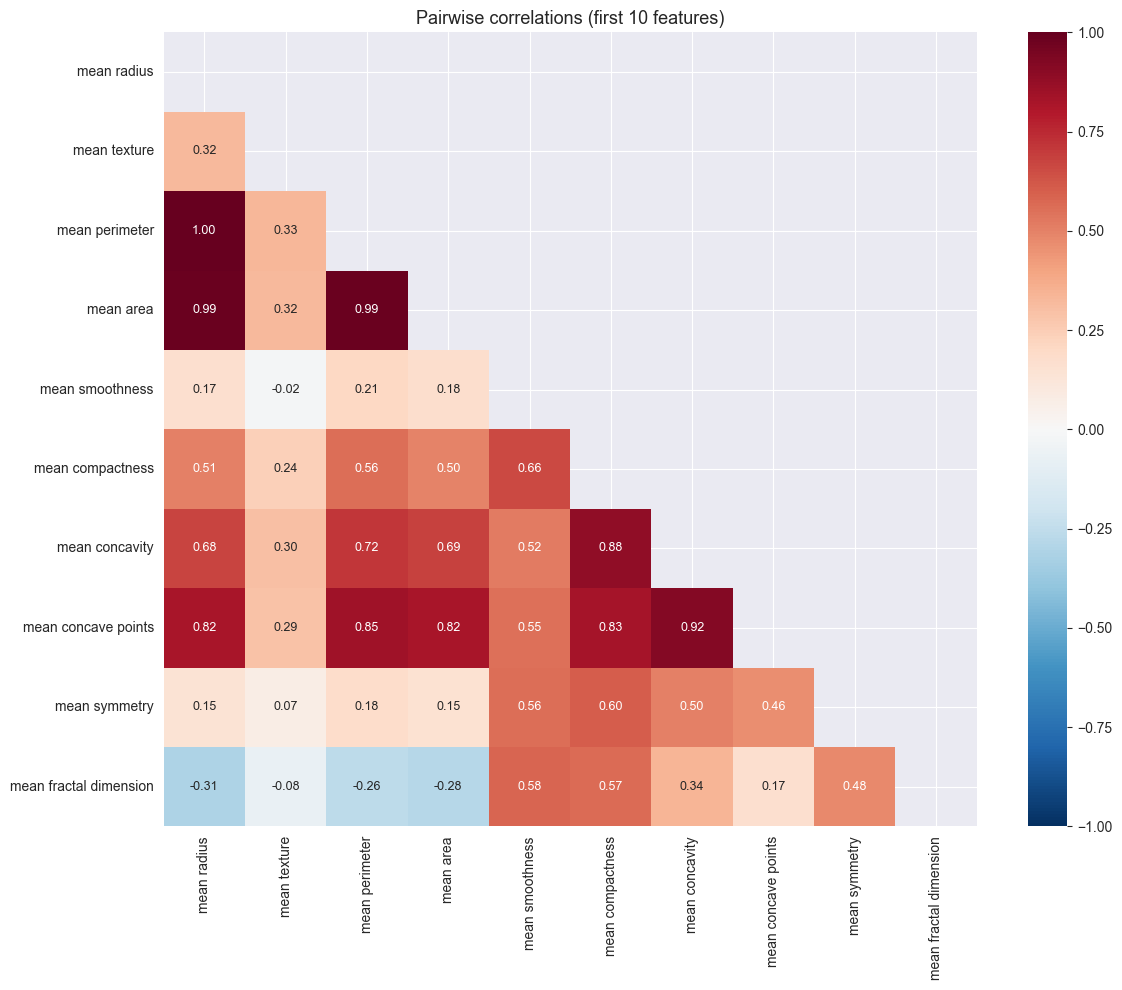

In [3]:
# Peek at feature correlations — this will be relevant later
fig, ax = plt.subplots(figsize=(12, 10))
corr = X.iloc[:, :10].corr()  # first 10 features
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, ax=ax, annot_kws={'size': 9})
ax.set_title('Pairwise correlations (first 10 features)', fontsize=13)
plt.tight_layout()
plt.show()

## Train / Test Split

We standardize the features (mean 0, std 1). Logistic regression is sensitive to feature scale; standardizing ensures fair comparison. Naive Bayes technically doesn't need it (it estimates its own means and variances), but applying it to both keeps the input identical.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape[0]} samples  |  Test: {X_test_s.shape[0]} samples')

Train: 455 samples  |  Test: 114 samples


---
## Model 1 — Logistic Regression

Logistic regression finds the linear combination of features $\mathbf{w}^\top \mathbf{x} + b$ whose sigmoid maps most cleanly to class labels. It does *not* model what the features look like within each class — it only cares about the boundary between them.

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

lr_pred  = lr.predict(X_test_s)
lr_proba = lr.predict_proba(X_test_s)[:, 1]  # P(benign)

print(f'Logistic Regression accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=['malignant', 'benign']))

Logistic Regression accuracy: 0.9825

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



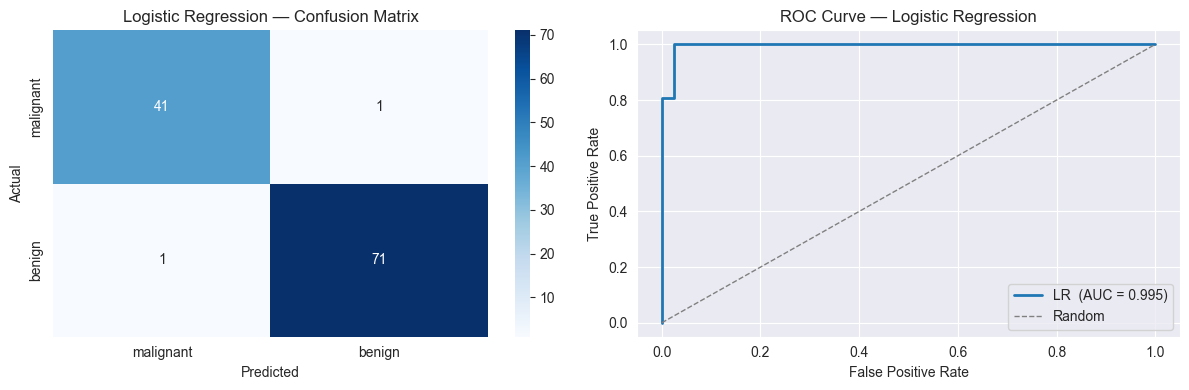

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['malignant','benign'], yticklabels=['malignant','benign'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Logistic Regression — Confusion Matrix')

# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
auc_lr = auc(fpr_lr, tpr_lr)
axes[1].plot(fpr_lr, tpr_lr, lw=2, label=f'LR  (AUC = {auc_lr:.3f})')
axes[1].plot([0,1],[0,1],'--',color='gray',lw=1,label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Model 2 — Gaussian Naive Bayes

GaussianNB fits a Gaussian distribution to each feature *within each class*, then applies Bayes' theorem at prediction time. Training is just computing 2 × 30 means and 2 × 30 standard deviations — no optimization loop at all.

The "naive" assumption: features are **independent** given the class. That's violated here (radius and area are almost perfectly correlated). We'll see whether that hurts.

In [7]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)

nb_pred  = nb.predict(X_test_s)
nb_proba = nb.predict_proba(X_test_s)[:, 1]

print(f'Naive Bayes accuracy: {accuracy_score(y_test, nb_pred):.4f}')
print()
print(classification_report(y_test, nb_pred, target_names=['malignant', 'benign']))

Naive Bayes accuracy: 0.9298

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



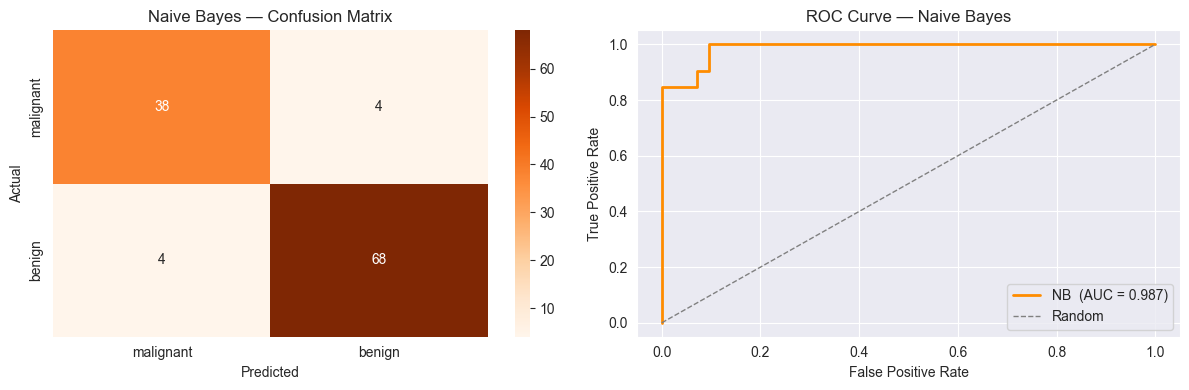

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_nb = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['malignant','benign'], yticklabels=['malignant','benign'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Naive Bayes — Confusion Matrix')

fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_proba)
auc_nb = auc(fpr_nb, tpr_nb)
axes[1].plot(fpr_nb, tpr_nb, color='darkorange', lw=2, label=f'NB  (AUC = {auc_nb:.3f})')
axes[1].plot([0,1],[0,1],'--',color='gray',lw=1,label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Naive Bayes')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Head-to-Head Comparison

In [9]:
# Summary table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Gaussian Naive Bayes'],
    'Accuracy': [accuracy_score(y_test, lr_pred), accuracy_score(y_test, nb_pred)],
    'ROC-AUC':  [auc_lr, auc_nb],
    'False Negatives\n(missed malignant)': [
        cm_lr[0, 1],  # actual=malignant, predicted=benign
        cm_nb[0, 1]
    ]
})
results.set_index('Model').round(4)

,Accuracy,ROC-AUC,False Negatives\n(missed malignant)
Model,,,
Logistic Regression,0.9825,0.9954,1
Gaussian Naive Bayes,0.9298,0.9868,4


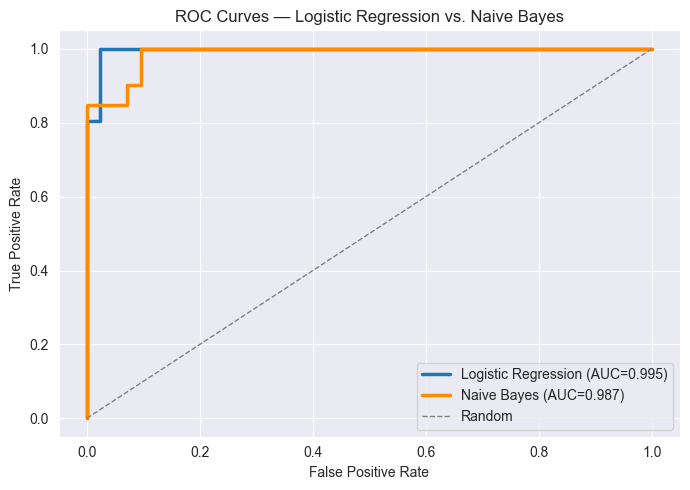

In [10]:
# Both ROC curves on the same axes
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, lw=2.5, label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot(fpr_nb, tpr_nb, lw=2.5, color='darkorange', label=f'Naive Bayes (AUC={auc_nb:.3f})')
ax.plot([0,1],[0,1],'--',color='gray',lw=1,label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Logistic Regression vs. Naive Bayes')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# Where do the models disagree?
disagree_mask = (lr_pred != nb_pred)
n_disagree = disagree_mask.sum()
print(f'Models disagree on {n_disagree} of {len(y_test)} test samples ({100*n_disagree/len(y_test):.1f}%)')

X_test_df = pd.DataFrame(X_test_s, columns=data.feature_names)
disagree_df = X_test_df[disagree_mask].copy()
disagree_df['true_label']  = y_test.values[disagree_mask]
disagree_df['lr_pred']     = lr_pred[disagree_mask]
disagree_df['nb_pred']     = nb_pred[disagree_mask]
disagree_df['lr_proba']    = lr_proba[disagree_mask].round(3)
disagree_df['nb_proba']    = nb_proba[disagree_mask].round(3)
disagree_df[['true_label','lr_pred','nb_pred','lr_proba','nb_proba']].head(10)

Models disagree on 6 of 114 test samples (5.3%)


,true_label,lr_pred,nb_pred,lr_proba,nb_proba
30,1,1,0,0.992,0.029
35,0,0,1,0.188,1.000
65,0,0,1,0.133,1.000
84,0,0,1,0.352,0.953
108,1,1,0,1.000,0.256
110,1,1,0,0.852,0.000


---
## Discussion Questions

1. **Accuracy**: Which model is more accurate? Is the difference larger or smaller than you expected?

2. **False negatives**: In a cancer screening context, a false negative means a malignant tumour is classified as benign. Which model produces more false negatives? What are the consequences of that difference?

3. **The independence assumption**: Look back at the correlation heatmap. Several features are very strongly correlated (e.g., `mean radius`, `mean perimeter`, `mean area`). Naive Bayes treats them as independent — it essentially counts their evidence multiple times. How does that show up in the model's predictions or probability estimates?

4. **Probability calibration**: When both models predict class probabilities, are those probabilities equally trustworthy? Compare the histogram of predicted probabilities for each model. Which model seems more confident? Is more confident always better?

5. **Speed vs. accuracy**: Naive Bayes trained instantly with no optimization. Logistic regression ran gradient descent for up to 1000 iterations. If you had 10 million samples instead of 569, would that tradeoff change your model choice?

6. **Extension**: Try replacing `GaussianNB` with `BernoulliNB` or `MultinomialNB` (you'd need to binarize or re-scale the features). How does the choice of likelihood distribution affect performance?